In [1]:
import numpy as np
import OpenEXR
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

In [2]:
def read_exr_rgb(path):
    with OpenEXR.File(path) as exr:
        part = exr.parts[0]
        channels = part.channels
        rgb = channels["RGBA"].pixels[..., :3].astype(np.float32)
    return rgb

In [3]:
def get_blocks(img):
    blocks = []
    
    for i in range (0, 20):
        block = img[starting_y:starting_y+x_step, starting_x+(i*x_step):starting_x+(i+1)*x_step]
        blocks.append(block)

    return blocks

In [4]:
homePath = r"D:\ThesisData"

In [5]:
# change

currentFolder = r"\back_trees\1020\1715"

path = homePath + currentFolder
path

'D:\\ThesisData\\back_trees\\1020\\1715'

In [6]:
imageFolder = Path(path + r"\Color")
imageFolder

WindowsPath('D:/ThesisData/back_trees/1020/1715/Color')

In [7]:
counter = 0

for file in imageFolder.glob("*.exr"):
    file = str(file)

    img = read_exr_rgb(file)

    y, x, c = img.shape
    
    x_step = x//24
    starting_x = 2 * x_step
    
    starting_y = y//2-x_step//2

    blocks = get_blocks(img)
    blocks_np = np.stack(blocks)

    np.save(path + f"\\Processed\\proc_{counter}.npy", blocks_np)

    counter = counter + 1

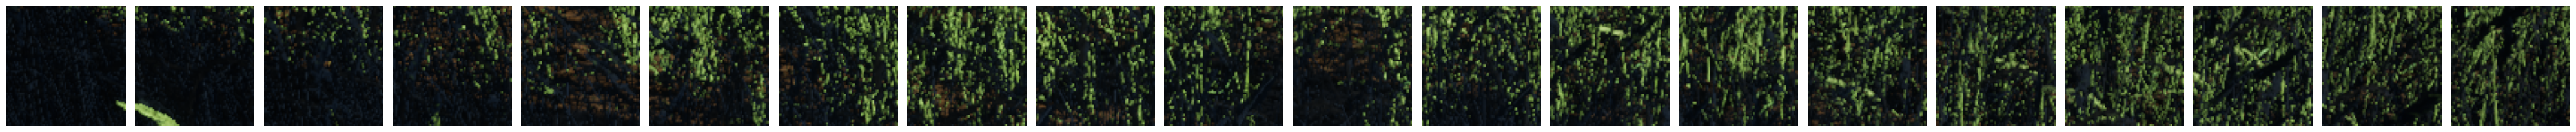

In [8]:
# validation

if True:
    test = np.load(path + r"\Processed\proc_78.npy")

    plt.figure(figsize=(40, 4))

    for i in range (0, len(test)):
        plt.subplot(1, len(test), i+1)
        plt.axis("off")
        plt.imshow(test[i])
    
    plt.tight_layout()
    plt.show()